In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#   kernelspec:
#     display_name: Python 3
#     language: python
#     name: python3
# ---

# centering의 메커니즘 — 로짓에서 EMA 평균을 빼면 무슨 일이 일어나는가

네 가지를 수치로 확인한다.

- (a) 한 차원이 계속 큰 편향 로짓에 `update_center`를 반복 적용 → center가 편향을 따라잡아 상쇄
- (b) 시프트 불변성 — center에 상수를 더해도 결과 동일. **편차 성분만이 작동한다**
- (c) `center_momentum` 0.5 / 0.9 / 0.99 / 0.999 → 느린 center는 급격한 붕괴를 놓친다
- (d) 균등 붕괴 상태에서는 center의 편차가 0으로 수렴 → centering이 무력 (사각지대)

In [2]:
import math

import numpy as np
import plotly.graph_objects as go
import torch
import torch.nn.functional as F
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


torch.manual_seed(0)

K = 16           # out_dim (원본은 65536, 여기선 보기 좋게 축소)
B = 256          # batch size
TEACHER_TEMP = 0.04
BIAS = 4.0       # 0번 차원에 걸린 고정 편향 (원-핫 붕괴로 미는 힘)
NOISE = 0.5      # 샘플별 로짓 변동


def update_center(center, teacher_output, m):
    """main_dino.py DINOLoss.update_center 와 동일 (all_reduce 만 제거)."""
    batch_center = teacher_output.mean(dim=0, keepdim=True)
    return center * m + batch_center * (1 - m)


def teacher_dist(logits, center, temp=TEACHER_TEMP):
    return F.softmax((logits - center) / temp, dim=-1)


print(f"K={K}  B={B}  teacher_temp={TEACHER_TEMP}  bias={BIAS}  log K = {math.log(K):.4f}")

K=16  B=256  teacher_temp=0.04  bias=4.0  log K = 2.7726


## (a) 편향 로짓 + `update_center` 반복 — center가 편향을 따라잡는 과정

teacher가 매 스텝 "0번 차원이 항상 +4"인 로짓을 낸다고 두고 (붕괴로 미는 고정 압력),
`update_center`만 반복 호출한다. 네트워크는 얼려 둔 셈이므로,
오직 center의 EMA 추적만이 분포를 바꾼다.

보는 지표는 **배치 평균 분포** $\bar q = \frac{1}{B}\sum_i q_i$ 다.
"한 차원이 지배한다"는 것은 $\bar q$ 가 한 칸에 몰린다는 뜻이고,
centering이 목표로 하는 것은 $\bar q$ 를 균등하게 만드는 것이다.
(샘플 개개의 $q_i$ 는 sharpening 때문에 여전히 뾰족하다 — 그건 이 카드의 관심사가 아니다.)

In [3]:
STEPS_A = 60
bias_vec = torch.zeros(1, K)
bias_vec[0, 0] = BIAS

center = torch.zeros(1, K)
mean_dists, max_share, center_dev, center0 = [], [], [], []
for t in range(STEPS_A):
    logits = bias_vec + NOISE * torch.randn(B, K)
    q = teacher_dist(logits, center)
    qbar = q.mean(dim=0)
    mean_dists.append(qbar.numpy().copy())
    max_share.append(qbar.max().item())
    center_dev.append((center - center.mean()).norm().item())
    center0.append(center[0, 0].item())
    center = update_center(center, logits, m=0.9)

mean_dists = np.array(mean_dists)          # (STEPS_A, K)
rows = [(t, max_share[t],
         float(-(mean_dists[t] * np.log(mean_dists[t] + 1e-12)).sum()),
         center0[t], center_dev[t])
        for t in range(STEPS_A)]

print("step | qbar.max |  h(qbar) | center[0] | center 편차노름")
for t in (0, 3, 6, 10, 15, 20, 30, 40, 59):
    s, mx, h, c0, dev = rows[t]
    print(f"{s:4d} | {mx:8.4f} | {h:8.4f} | {c0:9.4f} | {dev:14.4f}")
print(f"\nlog K = {math.log(K):.4f} (균등 배치평균의 엔트로피 상한)")

step | qbar.max |  h(qbar) | center[0] | center 편차노름
   0 |   1.0000 |   0.0000 |    0.0000 |         0.0000
   3 |   0.9961 |   0.0258 |    1.0773 |         1.0447
   6 |   0.9891 |   0.0761 |    1.8631 |         1.8052
  10 |   0.8015 |   1.0194 |    2.6042 |         2.5242
  15 |   0.5003 |   2.0334 |    3.1810 |         3.0811
  20 |   0.2608 |   2.5629 |    3.5195 |         3.4081
  30 |   0.1064 |   2.7428 |    3.8390 |         3.7179
  40 |   0.0948 |   2.7404 |    3.9461 |         3.8217
  59 |   0.0824 |   2.7601 |    3.9967 |         3.8717

log K = 2.7726 (균등 배치평균의 엔트로피 상한)


center[0]이 $4(1-0.9^t)$ 을 따라 `BIAS = 4.0` 으로 수렴한다 —
$1/(1-0.9) = 10$ 스텝이 시간상수이므로 30스텝(3τ)에 3.84, 60스텝(6τ)에 4.00.

주목할 점은 **$\bar q$ 가 center보다 늦게, 그리고 훨씬 급격하게 무너진다**는 것이다.
남은 편향 $4 - c_0$ 을 온도 $0.04$ 로 나눈 값이 실제 로짓 격차이므로,
$c_0 = 2.6$ (10스텝)일 때 남은 편향 1.4는 $1.4/0.04 = 35$ 로 아직 압도적이고,
$c_0 = 3.5$ (20스텝)에서 남은 편향 0.5가 $0.5/0.04 = 12.5$ 로 샘플 노이즈 $0.5/0.04$ 와
같은 스케일이 되는 순간 배치 평균이 급격히 흩어진다.
**온도로 나누기 때문에 조금 남은 편향도 크게 보인다 — centering은 sharpening과 싸우고 있다.**

## (b) 시프트 불변성 — 균일 성분은 아무 일도 하지 않는다

$$\mathrm{softmax}(z + a\mathbf{1}) = \mathrm{softmax}(z)$$

그러므로 center 벡터 $c$ 를 $c = \bar c\,\mathbf{1} + \tilde c$ 로 쪼개면
($\bar c$ = 차원 평균, $\tilde c$ = **편차**), 실제로 분포를 바꾸는 것은 $\tilde c$ 뿐이다.

In [4]:
c = center.clone()                       # (a)에서 학습된 center
logits = bias_vec + NOISE * torch.randn(B, K)

q_base = teacher_dist(logits, c)
q_shift = teacher_dist(logits, c + 137.0)          # 상수 137을 통째로 더함
q_dev = teacher_dist(logits, c - c.mean())         # 편차 성분만 남김
q_mean_only = teacher_dist(logits, c.mean().expand(1, K))  # 균일 성분만

print(f"center      = mean {c.mean():.4f}, 편차노름 {(c - c.mean()).norm():.4f}")
print(f"|q(c) - q(c+137)|_max      = {(q_base - q_shift).abs().max():.3e}   ← 0 (시프트 불변)")
print(f"|q(c) - q(c - mean(c))|_max = {(q_base - q_dev).abs().max():.3e}   ← 0 (편차만이 작동)")
print(f"|q(c) - q(mean(c)*1)|_max   = {(q_base - q_mean_only).abs().max():.3e}   ← 크다 (균일 성분만으론 무효과)")
print(f"|q(mean(c)*1) - q(0)|_max   = {(q_mean_only - teacher_dist(logits, torch.zeros(1, K))).abs().max():.3e}   ← 0 (균일 center == center 없음)")

# float64로 다시: 위의 8.98e-05는 float32 반올림 (137/0.04 = 3425를 exp에 넣는다)
c64, l64 = c.double(), logits.double()
d64 = (teacher_dist(l64, c64) - teacher_dist(l64, c64 + 137.0)).abs().max()
print(f"float64에서 |q(c) - q(c+137)|_max = {d64:.3e}   ← 진짜 0에 가깝다")

center      = mean 0.2471, 편차노름 3.8700
|q(c) - q(c+137)|_max      = 8.982e-05   ← 0 (시프트 불변)
|q(c) - q(c - mean(c))|_max = 8.941e-07   ← 0 (편차만이 작동)
|q(c) - q(mean(c)*1)|_max   = 1.000e+00   ← 크다 (균일 성분만으론 무효과)
|q(mean(c)*1) - q(0)|_max   = 2.439e-19   ← 0 (균일 center == center 없음)
float64에서 |q(c) - q(c+137)|_max = 0.000e+00   ← 진짜 0에 가깝다


결론: center의 **차원 간 편차** $\tilde c$ 가 centering의 전부다.
편차가 0이면 center를 빼는 연산은 항등연산이다 — 이 사실이 (d)의 사각지대로 직결된다.

곱셈적 억제 관점도 수치로 확인해 둔다:
$$\mathrm{softmax}(z-c)_i = \frac{p_i e^{-c_i/\tau}}{\sum_j p_j e^{-c_j/\tau}}$$

In [5]:
z = torch.tensor([[4.0, 0.0, 0.0, 0.0]])
c4 = torch.tensor([[3.0, 0.0, 0.0, 0.0]])
tau = 1.0
p = F.softmax(z / tau, dim=-1)
w = torch.exp(-c4 / tau)
reweighted = (p * w) / (p * w).sum()
direct = F.softmax((z - c4) / tau, dim=-1)
print("p           =", p.numpy().round(6))
print("e^{-c/tau}  =", w.numpy().round(6))
print("재가중 결과 =", reweighted.numpy().round(6))
print("직접 계산   =", direct.numpy().round(6))
print("일치?", torch.allclose(reweighted, direct, atol=1e-6))

p           = [[0.947915 0.017362 0.017362 0.017362]]
e^{-c/tau}  = [[0.049787 1.       1.       1.      ]]
재가중 결과 = [[0.475367 0.174878 0.174878 0.174878]]
직접 계산   = [[0.475367 0.174878 0.174878 0.174878]]
일치? True


## (c) `center_momentum` — 느린 center는 급격한 붕괴를 놓친다

이번엔 편향이 **시간에 따라 커진다**: $b_t = b_{\max}(1 - e^{-t/\lambda})$.
승자독식 피드백이 학습률에 이끌려 로짓을 밀어올리는 상황의 대역이다.
center EMA의 시간상수는 $1/(1-m)$ 스텝이므로, $m$ 이 클수록 추적이 느리다.

In [6]:
STEPS_C = 400
LAMBDA = 25.0     # 붕괴 피드백의 시간상수 (스텝)
BMAX = 8.0

bias_traj = BMAX * (1.0 - np.exp(-np.arange(STEPS_C) / LAMBDA))
momenta = [0.5, 0.9, 0.99, 0.999]
curves = {}
for m in momenta:
    torch.manual_seed(1)
    cen = torch.zeros(1, K)
    mx, dev = [], []
    for t in range(STEPS_C):
        bv = torch.zeros(1, K)
        bv[0, 0] = float(bias_traj[t])
        lg = bv + NOISE * torch.randn(B, K)
        qbar = teacher_dist(lg, cen).mean(dim=0)
        mx.append(qbar.max().item())
        dev.append(float((cen - cen.mean()).norm()))
        cen = update_center(cen, lg, m=m)
    curves[m] = (np.array(mx), np.array(dev))

print("m     | 시간상수 1/(1-m) | qbar.max @t=50 | @t=150 | @t=399 | 최종 center 편차노름")
for m in momenta:
    mx, dev = curves[m]
    print(f"{m:<5} | {1/(1-m):15.1f} | {mx[50]:14.4f} | {mx[150]:6.4f} | {mx[399]:6.4f} | {dev[-1]:20.4f}")
print(f"\n붕괴 피드백 시간상수 = {LAMBDA} 스텝. m=0.999의 center 시간상수 1000스텝은 이보다 40배 느리다.")
print(f"균등 배치평균 기준선 1/K = {1/K:.4f}")

m     | 시간상수 1/(1-m) | qbar.max @t=50 | @t=150 | @t=399 | 최종 center 편차노름
0.5   |             2.0 |         0.0984 | 0.0865 | 0.0882 |               7.7532
0.9   |            10.0 |         0.3878 | 0.0873 | 0.0834 |               7.7450
0.99  |           100.0 |         1.0000 | 0.9909 | 0.1205 |               7.5581
0.999 |          1000.0 |         1.0000 | 1.0000 | 1.0000 |               2.4138

붕괴 피드백 시간상수 = 25.0 스텝. m=0.999의 center 시간상수 1000스텝은 이보다 40배 느리다.
균등 배치평균 기준선 1/K = 0.0625


논문 Appendix D의 `Online centering` 표와 정확히 같은 그림이다:
$m \in \{0, 0.9, 0.99\}$ 는 k-NN 69.1 / 69.7 / 69.4 로 모두 멀쩡하고, $m = 0.999$ 만 0.1 (붕괴).
여기서도 0.5 / 0.9 / 0.99 는 결국 $\bar q$ 를 $1/K$ 로 되돌리지만 0.999는 400스텝 내내 못 따라잡는다.

## (d) 사각지대 — 균등 붕괴에서는 center 편차가 0으로 죽는다

두 붕괴 상태를 나란히 놓고 center 편차노름 $\lVert \tilde c \rVert$ 를 추적한다.

- **원-핫 붕괴**: 모든 샘플의 로짓이 0번 차원에 몰림 → 편차 $\to$ 큼 → centering이 강하게 작동
- **균등 붕괴**: 모든 샘플이 동일한 균등 로짓 → 배치 평균도 균등 → 편차 $\to 0$ → centering은 항등연산

In [7]:
STEPS_D = 200
runs = {}
for name in ("one-hot collapse", "uniform collapse"):
    torch.manual_seed(2)
    cen = torch.zeros(1, K)
    # 균등 붕괴에서 오는 잔여 편차를 보기 위해 center를 미리 원-핫 쪽으로 데워 둔다
    cen[0, 0] = 3.0
    dev, hbar = [], []
    for t in range(STEPS_D):
        if name == "one-hot collapse":
            lg = bias_vec + NOISE * torch.randn(B, K)
        else:
            lg = torch.zeros(B, K)          # 입력과 무관하게 완전히 동일·균등한 로짓
        qbar = teacher_dist(lg, cen).mean(dim=0)
        dev.append(float((cen - cen.mean()).norm()))
        hbar.append(float(-(qbar * torch.log(qbar + 1e-12)).sum()))
        cen = update_center(cen, lg, m=0.9)
    runs[name] = (np.array(dev), np.array(hbar))

print("step | one-hot: 편차노름 / h(qbar) | uniform: 편차노름 / h(qbar)")
for t in (0, 10, 30, 60, 120, 199):
    d1, h1 = runs["one-hot collapse"][0][t], runs["one-hot collapse"][1][t]
    d2, h2 = runs["uniform collapse"][0][t], runs["uniform collapse"][1][t]
    print(f"{t:4d} | {d1:12.4f} / {h1:7.4f}    | {d2:12.4f} / {h2:7.4f}")

# 사각지대의 결정적 증거: 균등 붕괴 상태에서 center를 빼도 분포가 안 바뀐다
flat = torch.zeros(B, K)
cen_uni = torch.zeros(1, K)
cen_uni[0, 0] = 3.0
for _ in range(200):
    cen_uni = update_center(cen_uni, flat, m=0.9)
print(f"\n균등 붕괴 수렴 center = {cen_uni.numpy().round(8)}")
print(f"편차노름 = {(cen_uni - cen_uni.mean()).norm():.3e}")
print("centering 적용 전후 분포 차이 =",
      float((teacher_dist(flat, cen_uni) - teacher_dist(flat, torch.zeros(1, K))).abs().max()))
print(f"h(qbar) = {math.log(K):.4f} = log K — 이미 균등, centering이 고칠 것이 없다")

step | one-hot: 편차노름 / h(qbar) | uniform: 편차노름 / h(qbar)
   0 |       2.9047 /  1.7267    |       2.9047 /  2.7081
  10 |       3.5297 /  2.6499    |       1.0128 /  2.7081
  30 |       3.8318 /  2.7340    |       0.1231 /  2.7196
  60 |       3.8670 /  2.7534    |       0.0052 /  2.7721
 120 |       3.8741 /  2.7535    |       0.0000 /  2.7726
 199 |       3.8824 /  2.7613    |       0.0000 /  2.7726

균등 붕괴 수렴 center = [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
편차노름 = 2.049e-09
centering 적용 전후 분포 차이 = 3.725290298461914e-09
h(qbar) = 2.7726 = log K — 이미 균등, centering이 고칠 것이 없다


주의: `h(qbar)` 는 두 경우 모두 $\log K$ 로 같다. 배치 평균만 봐서는 두 상태를 구분할 수 없다 —
centering은 애초에 배치 평균만 보는 장치이므로, 균등 붕괴를 **감지할 수단조차 없다**.
구분하려면 샘플별 엔트로피 $h(q_i)$ 를 봐야 하고, 그것을 낮추는 것은 sharpening의 일이다.

## 그림

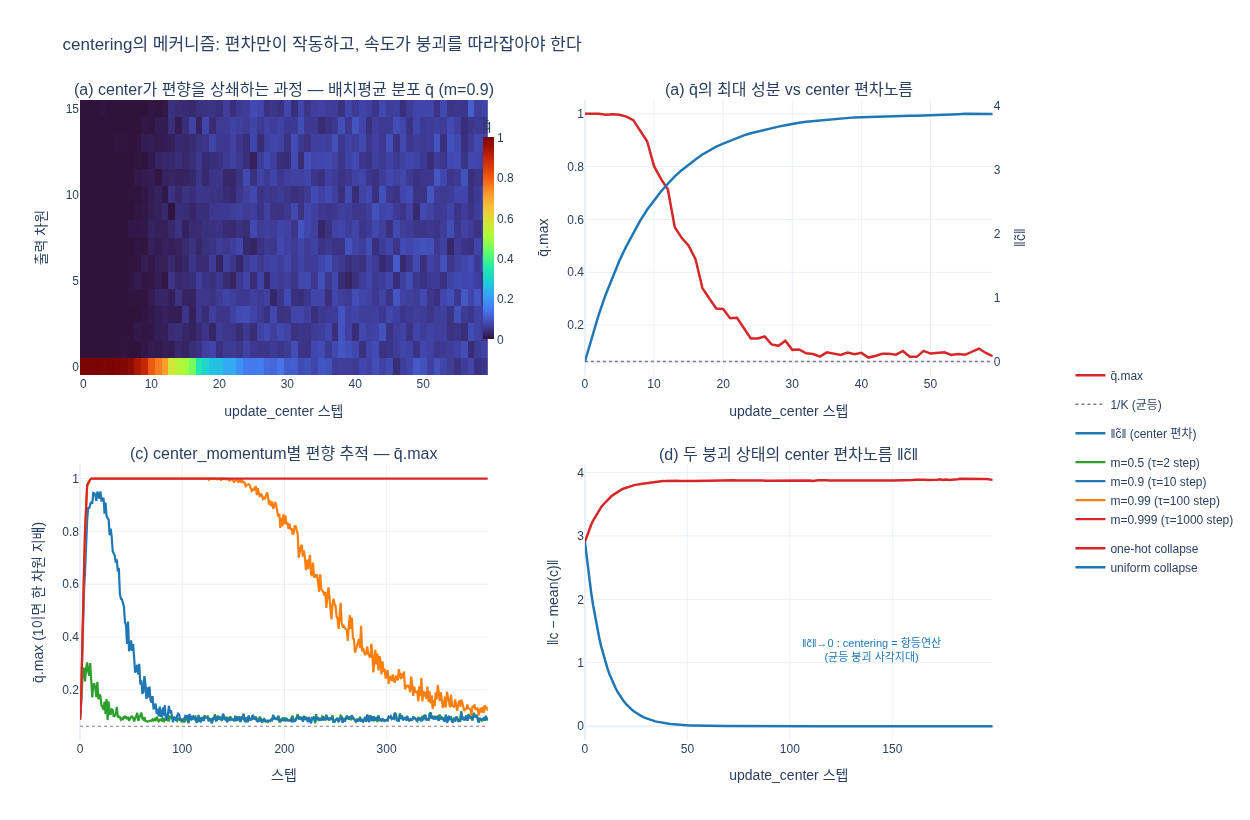

saved expy.png


In [8]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "(a) center가 편향을 상쇄하는 과정 — 배치평균 분포 q̄ (m=0.9)",
        "(a) q̄의 최대 성분 vs center 편차노름",
        "(c) center_momentum별 편향 추적 — q̄.max",
        "(d) 두 붕괴 상태의 center 편차노름 ‖c̃‖",
    ),
    specs=[[{"type": "heatmap"}, {"secondary_y": True}],
           [{}, {}]],
    vertical_spacing=0.14, horizontal_spacing=0.10,
)

# (a) heatmap
fig.add_trace(
    go.Heatmap(z=mean_dists.T, x=list(range(STEPS_A)), y=list(range(K)),
               colorscale="Turbo", zmin=0, zmax=1,
               colorbar=dict(title="q̄", len=0.38, y=0.80, x=0.405, thickness=11)),
    row=1, col=1,
)
fig.update_xaxes(title_text="update_center 스텝", row=1, col=1)
fig.update_yaxes(title_text="출력 차원", row=1, col=1)

# (a) 곡선
steps_a = list(range(STEPS_A))
fig.add_trace(go.Scatter(x=steps_a, y=[r[1] for r in rows], name="q̄.max",
                         line=dict(color="#d62728", width=2.5)),
              row=1, col=2, secondary_y=False)
fig.add_trace(go.Scatter(x=steps_a, y=[1 / K] * STEPS_A, name="1/K (균등)",
                         line=dict(color="#7f7f7f", width=1.5, dash="dot")),
              row=1, col=2, secondary_y=False)
fig.add_trace(go.Scatter(x=steps_a, y=[r[4] for r in rows], name="‖c̃‖ (center 편차)",
                         line=dict(color="#1f77b4", width=2.5)),
              row=1, col=2, secondary_y=True)
fig.update_xaxes(title_text="update_center 스텝", row=1, col=2)
fig.update_yaxes(title_text="q̄.max", row=1, col=2, secondary_y=False)
fig.update_yaxes(title_text="‖c̃‖", row=1, col=2, secondary_y=True, showgrid=False)

# (c) 모멘텀
palette = {0.5: "#2ca02c", 0.9: "#1f77b4", 0.99: "#ff7f0e", 0.999: "#d62728"}
for m in momenta:
    mx, _ = curves[m]
    fig.add_trace(go.Scatter(x=list(range(STEPS_C)), y=mx,
                             name=f"m={m} (τ={1/(1-m):.0f} step)",
                             line=dict(color=palette[m], width=2.2),
                             legendgroup="mom"),
                  row=2, col=1)
fig.add_trace(go.Scatter(x=list(range(STEPS_C)), y=[1 / K] * STEPS_C,
                         name="1/K", showlegend=False,
                         line=dict(color="#7f7f7f", width=1.2, dash="dot")),
              row=2, col=1)
fig.update_xaxes(title_text="스텝", row=2, col=1)
fig.update_yaxes(title_text="q̄.max (1이면 한 차원 지배)", row=2, col=1)

# (d) 편차노름
for name, color in (("one-hot collapse", "#d62728"), ("uniform collapse", "#1f77b4")):
    dev, _ = runs[name]
    fig.add_trace(go.Scatter(x=list(range(STEPS_D)), y=dev, name=name,
                             line=dict(color=color, width=2.5), legendgroup="dev"),
                  row=2, col=2)
fig.add_annotation(x=140, y=0.35, xref="x4", yref="y4", showarrow=False,
                   text="‖c̃‖→0 : centering = 항등연산<br>(균등 붕괴 사각지대)",
                   font=dict(size=11, color="#1f77b4"))
fig.update_xaxes(title_text="update_center 스텝", row=2, col=2)
fig.update_yaxes(title_text="‖c − mean(c)‖", row=2, col=2)

fig.update_layout(
    height=820, width=1250,
    title_text="centering의 메커니즘: 편차만이 작동하고, 속도가 붕괴를 따라잡아야 한다",
    template="plotly_white", font=dict(size=12),
    legend=dict(orientation="v", x=1.02, y=0.42),
)

fig.write_image("/home/sungwoo/projects/swcho/dino/fm/entropy/.fm/hints/"
                "b6455eb5-dda0-439c-87bd-e7be15e4b448/expy.png", scale=2)
_show(fig)
print("saved expy.png")